In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [3]:
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. Base Project Assumptions (10 MW / 20 MWh BESS in Germany)
# ---------------------------------------------------------
PROJECT_CAPEX = 6_000_000      # Total CAPEX in EUR (approx. 300k EUR/MWh)
ANNUAL_OPEX = 150_000          # Fixed O&M, Insurance, Land lease (EUR/year)
PROJECT_LIFETIME = 15          # Technical lifetime in years
DEBT_TENOR = 10                # Debt repayment period in years
INTEREST_RATE = 0.05           # Annual interest rate (5%)
CORPORATE_TAX_RATE = 0.30      # German corporate tax rate (~30%)

# ---------------------------------------------------------
# 2. Market Strategies & Bankability Parameters
# ---------------------------------------------------------
# German banks require higher DSCR for riskier cash flows.
# Tolling = Fixed capacity payment (Low Risk)
# Floor = Merchant with downside protection (Medium Risk)
# Merchant = Fully exposed to spot/balancing market (High Risk)

scenarios = {
    "Pure Merchant": {
        "annual_revenue": 1_200_000,  # High potential return
        "target_dscr": 1.75           # High risk -> Bank demands high buffer
    },
    "Merchant with Floor": {
        "annual_revenue": 950_000,    # Upside shared/capped, downside protected
        "target_dscr": 1.40           # Medium risk
    },
    "Tolling Agreement": {
        "annual_revenue": 700_000,    # Fixed predictable income (Availability based)
        "target_dscr": 1.20           # Low risk -> Bank accepts lower buffer
    }
}

# ---------------------------------------------------------
# 3. Financial Helper Functions
# ---------------------------------------------------------
def calculate_pv_of_annuity(payment, rate, periods):
    """
    Calculates the Present Value (PV) of an ordinary annuity.
    Formula: PV = P * [1 - (1 + r)^-n] / r
    """
    if rate == 0:
        return payment * periods
    return payment * (1 - (1 + rate)**-periods) / rate

def evaluate_bess_scenario(scenario_name, params):
    """
    Calculates CFADS, Debt Capacity, and Gearing Ratio for a given scenario.
    """
    # EBITDA estimation (Revenue - OPEX)
    ebitda = params["annual_revenue"] - ANNUAL_OPEX

    # Simplified tax estimation (EBITDA * Tax Rate) for CFADS approximation
    # In a full model, depreciation and interest tax shields are modeled per year.
    tax_estimate = ebitda * CORPORATE_TAX_RATE

    # Cash Flow Available for Debt Service (CFADS)
    cfads = ebitda - tax_estimate

    # Maximum Annual Debt Service the project can support based on Target DSCR
    # Formula: DSCR = CFADS / Debt Service -> Debt Service = CFADS / DSCR
    max_annual_debt_service = cfads / params["target_dscr"]

    # Debt Size (Capacity) based on the Present Value of the max debt service
    debt_size = calculate_pv_of_annuity(
        payment=max_annual_debt_service,
        rate=INTEREST_RATE,
        periods=DEBT_TENOR
    )

    # Ensure debt size does not exceed CAPEX (Gearing max 100%)
    debt_size = min(debt_size, PROJECT_CAPEX)

    # Calculate Gearing (Debt to Total CAPEX ratio)
    gearing = debt_size / PROJECT_CAPEX
    equity_size = PROJECT_CAPEX - debt_size

    return {
        "Strategy": scenario_name,
        "Target DSCR": params["target_dscr"],
        "Annual Revenue (€)": params["annual_revenue"],
        "CFADS (€)": cfads,
        "Max Debt Service (€)": max_annual_debt_service,
        "Debt Capacity (€)": debt_size,
        "Equity Required (€)": equity_size,
        "Gearing Ratio (%)": gearing * 100
    }

print("Base parameters and financial functions loaded successfully.")

Base parameters and financial functions loaded successfully.


In [4]:
# ---------------------------------------------------------
# 4. Scenario Analysis & Output Table
# ---------------------------------------------------------
results = []
for name, params in scenarios.items():
    res = evaluate_bess_scenario(name, params)
    results.append(res)

# Create a Pandas DataFrame for clean visualization
df_results = pd.DataFrame(results)

# Format the dataframe for better readability
format_dict = {
    "Target DSCR": "{:.2f}x",
    "Annual Revenue (€)": "{:,.0f}",
    "CFADS (€)": "{:,.0f}",
    "Max Debt Service (€)": "{:,.0f}",
    "Debt Capacity (€)": "{:,.0f}",
    "Equity Required (€)": "{:,.0f}",
    "Gearing Ratio (%)": "{:.1f}%"
}

# Display the styled table
styled_df = df_results.style.format(format_dict).set_caption("BESS Offtake Bankability Comparison (Germany)")
styled_df

,Strategy,Target DSCR,Annual Revenue (€),CFADS (€),Max Debt Service (€),Debt Capacity (€),Equity Required (€),Gearing Ratio (%)
0,Pure Merchant,1.75x,"1,200,000","735,000","420,000","3,243,129","2,756,871",54.1%
1,Merchant with Floor,1.40x,"950,000","560,000","400,000","3,088,694","2,911,306",51.5%
2,Tolling Agreement,1.20x,"700,000","385,000","320,833","2,477,390","3,522,610",41.3%


In [6]:
# نصب کتابخانه محاسبات مالی به صورت خودکار
!pip install numpy-financial -q

# ---------------------------------------------------------
# 5. Cash Flow Waterfall & Equity IRR Calculation
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import numpy_financial as npf

irr_results = []

# حلقه روی نتایجی که در سلول قبلی محاسبه کردیم
for res in results:
    strategy_name = res["Strategy"]
    equity_invested = res["Equity Required (€)"]
    cfads = res["CFADS (€)"]
    annual_debt_service = res["Max Debt Service (€)"]

    # سال صفر: تزریق سرمایه اولیه توسط سرمایه‌گذار (جریان نقدینگی منفی)
    equity_cash_flows = [-equity_invested]

    # شبیه‌سازی ۱۵ سال عمر پروژه
    for year in range(1, PROJECT_LIFETIME + 1):
        if year <= DEBT_TENOR:
            # سال‌های ۱ تا ۱۰: پرداخت اقساط وام بانک
            cash_to_equity = cfads - annual_debt_service
        else:
            # سال‌های ۱۱ تا ۱۵: وام کاملاً تسویه شده و تمام سود به سرمایه‌گذار می‌رسد
            cash_to_equity = cfads

        equity_cash_flows.append(cash_to_equity)

    # محاسبه نرخ بازده داخلی سرمایه (Equity IRR)
    equity_irr = npf.irr(equity_cash_flows)

    # محاسبه دوره بازگشت سرمایه ساده (Payback Period)
    cumulative_cf = np.cumsum(equity_cash_flows)
    try:
        payback_year = np.where(cumulative_cf >= 0)[0][0]
    except IndexError:
        payback_year = ">15 (Never)"

    irr_results.append({
        "Strategy": strategy_name,
        "Equity Required (€)": equity_invested,
        "Avg Cash to Equity (Yr 1-10)": cfads - annual_debt_service,
        "Avg Cash to Equity (Yr 11-15)": cfads,
        "Payback Period (Years)": payback_year,
        "Equity IRR (%)": equity_irr * 100
    })

# ساخت و فرمت‌دهی جدول خروجی
df_irr = pd.DataFrame(irr_results)

format_irr = {
    "Equity Required (€)": "{:,.0f}",
    "Avg Cash to Equity (Yr 1-10)": "{:,.0f}",
    "Avg Cash to Equity (Yr 11-15)": "{:,.0f}",
    "Equity IRR (%)": "{:.2f}%"
}

styled_irr = df_irr.style.format(format_irr).set_caption("BESS Equity IRR & Cash Flow Analysis")
styled_irr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 5.6 MB/s eta 0:00:00


,Strategy,Equity Required (€),Avg Cash to Equity (Yr 1-10),Avg Cash to Equity (Yr 11-15),Payback Period (Years),Equity IRR (%)
0,Pure Merchant,"2,756,871","315,000","735,000",9,11.30%
1,Merchant with Floor,"2,911,306","160,000","560,000",13,4.26%
2,Tolling Agreement,"3,522,610","64,167","385,000",>15 (Never),-2.76%


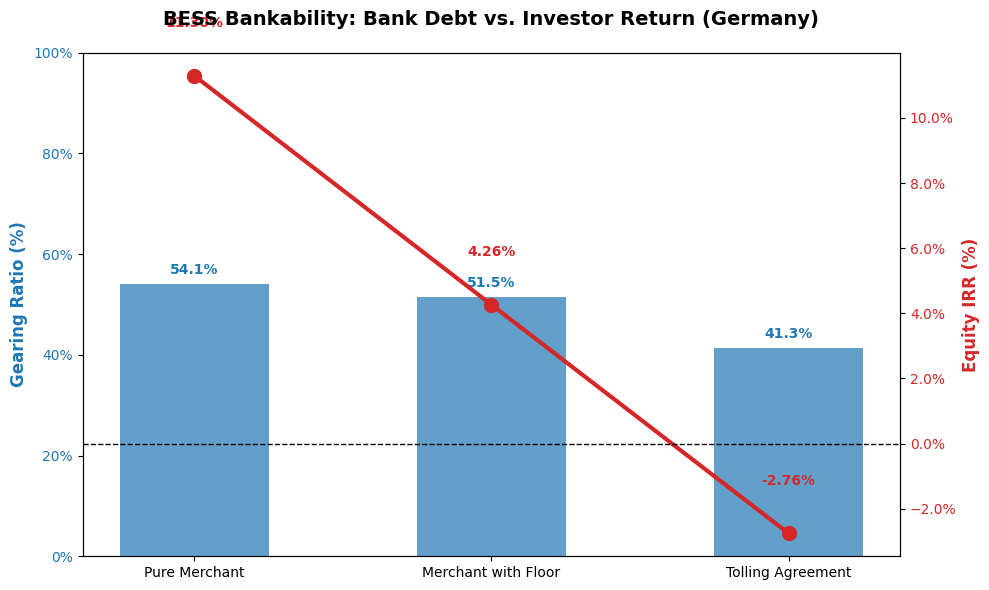

✅ تصویر نمودار با نام bess_financial_chart.png ذخیره شد.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# استخراج مستقیم داده‌ها (چون مقادیر داخل دیتافریم از نوع float هستند)
strategies = df_irr["Strategy"].tolist()
irrs = df_irr["Equity IRR (%)"].tolist()
gearings = df_results["Gearing Ratio (%)"].tolist()

# تنظیمات نمودار
fig, ax1 = plt.subplots(figsize=(10, 6))

# محور اول: Gearing Ratio (نمودار میله‌ای)
color1 = '#1f77b4'
bars = ax1.bar(strategies, gearings, color=color1, alpha=0.7, width=0.5, label='Gearing Ratio (Bank Debt %)')
ax1.set_ylabel('Gearing Ratio (%)', color=color1, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 100)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

# محور دوم: Equity IRR (نمودار خطی)
ax2 = ax1.twinx()
color2 = '#d62728'
line = ax2.plot(strategies, irrs, color=color2, marker='o', markersize=10, linewidth=3, label='Equity IRR (%)')
ax2.set_ylabel('Equity IRR (%)', color=color2, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(0, color='black', linewidth=1, linestyle='--') # خط صفر درصد
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())

# اضافه کردن مقادیر روی نمودار
for i, v in enumerate(gearings):
    ax1.text(i, v + 2, f"{v:.1f}%", ha='center', color=color1, fontweight='bold')
for i, v in enumerate(irrs):
    ax2.text(i, v + 1.5, f"{v:.2f}%", ha='center', color=color2, fontweight='bold')

plt.title('BESS Bankability: Bank Debt vs. Investor Return (Germany)', fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

# ذخیره تصویر برای استفاده در گیت‌هاب/لینکدین
plt.savefig('bess_financial_chart.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ تصویر نمودار با نام bess_financial_chart.png ذخیره شد.")